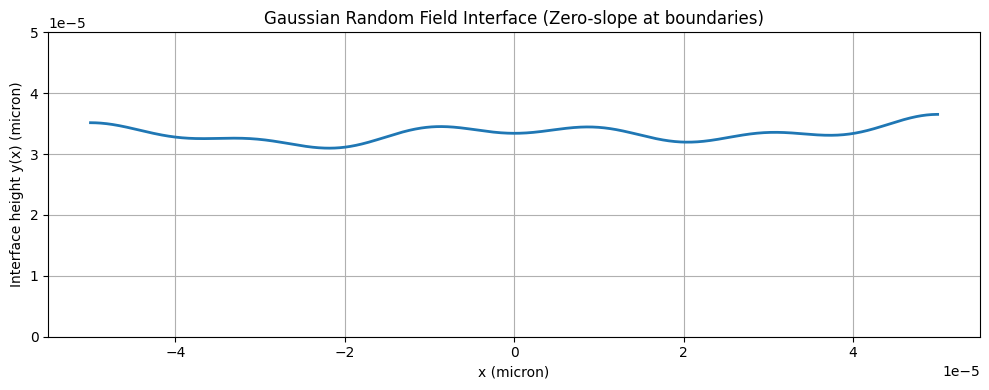

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------
# 1. Gaussian Random Field 随机界面
# ---------------------------
def make_random_profile_with_phase(xmin, xmax, n_modes=6, amp_scale=0.25, seed=None):
    """
    带相位的版本，使用 cos(πnx/L) 确保边界条件
    注意：这里使用 πn 而不是 2πn，这样半波长模式也能被包含
    """
    rng = np.random.default_rng(seed)
    L = xmax - xmin
    
    # 使用整数倍的半波模式
    ks = np.arange(1, n_modes + 1)
    amps = rng.normal(scale=amp_scale / np.sqrt(ks), size=ks.shape)
    
    def profile(x):
        xi = (np.asarray(x) - xmin) / L
        
        sum_val = np.zeros_like(xi, dtype=float)
        for k, a in zip(ks, amps):
            # cos(πkξ) 在 ξ=0 和 ξ=1 处导数为零
            # k=1: 半波, k=2: 全波, k=3: 1.5波, ...
            sum_val += a * np.cos(np.pi * k * xi)
        
        base = L2[1] / 3 * 2
        return np.clip(base + sum_val, *L2)
    
    return profile
# ---------------------------
# 2. 测试界面
# ---------------------------
L1 = [-50e-6, 50e-6]   # x 范围 (和你的代码一致)
L2 = [0, 50e-6]        # y 范围

profile = make_random_profile_with_phase(
    xmin=L1[0], 
    xmax=L1[1],
    n_modes=10,
    amp_scale=2.0e-6,
)

# 采样
x = np.linspace(L1[0], L1[1], 1000)
y = profile(x)

# ---------------------------
# 3. 绘图
# ---------------------------
plt.figure(figsize=(10,4))
plt.plot(x, y, linewidth=2)
plt.title("Gaussian Random Field Interface (Zero-slope at boundaries)")
plt.xlabel("x (micron)")
plt.ylabel("Interface height y(x) (micron)")
plt.grid(True)
plt.ylim(L2[0], L2[1])
plt.tight_layout()
plt.show()
